Cell 1: Install and import libraries

In [3]:
!pip install matplotlib --quiet
!pip install -U matplotlib


import numpy as np
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib import animation
from IPython.display import HTML
import pickle


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 54.4 MB/s eta 0:00:00
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.10.0
    Uninstalling matplotlib-3.10.0:
      Successfully uninstalled matplotlib-3.10.0


Cell 2: Define global game parameters

In [ ]:
# Global game parameters
GRID_WIDTH = 15
GRID_HEIGHT = 10
NUM_MOUNTAINS = 10
NUM_DRONES = 4
MAX_TURNS = 30
MAX_MISSILES = 3      # Maximum missiles aircraft can carry
INITIAL_MISSILES = 2  # Starting missiles for aircraft

# Scoring values (Aircraft and Drone)
AIRCRAFT_GOAL_SCORE = 1000      # if goal reached (after eliminating all drones)
AIRCRAFT_KILL_SCORE = 250       # per drone shot down
AIRCRAFT_CRASH_PENALTY = -500   # if crashes into mountain
AIRCRAFT_LOSS = -1000           # if drones win (surrounded or swarmed)

DRONE_WIN_SCORE = 500           # per drone if win by swarm/surround
DRONE_LOSS_PENALTY = -250       # per drone destroyed

# Movement directions
DIRECTIONS = {'UP': (0, -1), 'DOWN': (0, 1),
              'LEFT': (-1, 0), 'RIGHT': (1, 0), 'STAY': (0, 0)}

Cell 3: Define aircraft characteristics

In [ ]:
# For function approximation, we define separate feature vectors for aircraft and drones
def extract_aircraft_features(state):
    """
    Features for aircraft:
    - distance to each drone (for hunting)
    - distance to closest drone (hunting priority)
    - direction to closest drone (for hunting)
    - distance to goal
    - distance to reload zone
    - number of drones within shooting range (2-block)
    - number of drones within danger range (1-block)
    - count of drones in line of sight (shootable)
    - distance to nearest mountain (obstacle avoidance)
    - number of missiles (weapon status)
    - drones remaining ratio (mission progress)
    - in capture danger (drones that could move onto aircraft position)
    """
    feats = []
    # aircraft, goal and reload zone positions
    ax, ay = state['aircraft']
    gx, gy = state['goal']
    rx, ry = state['reload_zone']

    # Distance to goal (normalized)
    goal_dist = np.sqrt((ax - gx)**2 + (ay - gy)**2) / np.sqrt(GRID_WIDTH**2 + GRID_HEIGHT**2)
    feats.append(goal_dist)

    # Distance to reload zone (normalized)
    reload_dist = np.sqrt((ax - rx)**2 + (ay - ry)**2) / np.sqrt(GRID_WIDTH**2 + GRID_HEIGHT**2)
    feats.append(reload_dist)

    # Drones remaining ratio (how many drones still need to be eliminated)
    drones_remaining = len(state['drones']) / NUM_DRONES
    feats.append(drones_remaining)

    # Distances to each drone (up to 4 drones)
    drone_distances = []
    for i in range(NUM_DRONES):
        if i < len(state['drones']):
            dx, dy = state['drones'][i]
            dist = np.sqrt((ax - dx)**2 + (ay - dy)**2) / np.sqrt(GRID_WIDTH**2 + GRID_HEIGHT**2)
            drone_distances.append(dist)
            feats.append(dist)
        else:
            feats.append(1.0)  # if drone is not present, set distance high
            drone_distances.append(1.0)

    # Distance to closest drone (for prioritizing the nearest target)
    if drone_distances:
        closest_drone_dist = min(drone_distances)
        feats.append(closest_drone_dist)

        # Direction to closest drone
        closest_idx = drone_distances.index(closest_drone_dist)
        if closest_idx < len(state['drones']):
            dx, dy = state['drones'][closest_idx]
            direction_x = 0
            direction_y = 0
            if closest_drone_dist > 0:
                direction_x = (dx - ax) / (abs(dx - ax) if abs(dx - ax) > 0 else 1)
                direction_y = (dy - ay) / (abs(dy - ay) if abs(dy - ay) > 0 else 1)
            feats.append(direction_x)
            feats.append(direction_y)
        else:
            feats.append(0)  # No direction if no drone
            feats.append(0)
    else:
        feats.append(1.0)  # No closest drone
        feats.append(0)    # No direction
        feats.append(0)

    # Number of drones within 1-block (danger range)
    count_1 = sum(1 for d in state['drones'] if max(abs(ax - d[0]), abs(ay - d[1])) <= 1)
    feats.append(count_1 / NUM_DRONES)

    # Number of drones within 2-block range (for shooting)
    count_2 = sum(1 for d in state['drones'] if max(abs(ax - d[0]), abs(ay - d[1])) <= 2)
    feats.append(count_2 / NUM_DRONES)

    # Count of drones in line of sight (shootable)
    shootable_count = 0
    for d in state['drones']:
        if max(abs(ax - d[0]), abs(ay - d[1])) <= 2:  # Within range
            if line_of_sight_clear(state['aircraft'], d, state['mountains']):
                shootable_count += 1
    feats.append(shootable_count / NUM_DRONES)

    # Capture danger: count drones that are 1 step away from aircraft position
    capture_danger = 0
    for d in state['drones']:
        dx, dy = d
        # Check if drone is exactly 1 step away (can move onto aircraft position)
        if abs(ax - dx) <= 1 and abs(ay - dy) <= 1 and (ax != dx or ay != dy):
            capture_danger += 1
    feats.append(capture_danger / NUM_DRONES)

    # Hunting mode indicator (should prioritize hunting if missiles available and drones nearby)
    hunting_mode = min(state['aircraft_missiles'], 1) * min(1, count_2)  # 1 if has missiles and drones in range
    feats.append(hunting_mode)

    # Distance to nearest mountain (for obstacle avoidance)
    if state['mountains']:
        mountain_dists = [np.sqrt((ax - mx)**2 + (ay - my)**2) for mx, my in state['mountains']]
        nearest_mountain_dist = min(mountain_dists) / np.sqrt(GRID_WIDTH**2 + GRID_HEIGHT**2)
        feats.append(nearest_mountain_dist)
    else:
        feats.append(1.0)  # no mountains, set to maximum normalized distance

    # Normalized missile count (aircraft rockets count)
    feats.append(state['aircraft_missiles'] / MAX_MISSILES)

    # Danger level - combination of nearby drones and missile status
    danger_level = (count_1 / NUM_DRONES) * (MAX_MISSILES - state['aircraft_missiles']) / MAX_MISSILES
    feats.append(danger_level)

    return np.array(feats)

Cell 4: Defining the characteristics of drones

In [ ]:
def extract_drone_features(state, drone_idx):
    """
    Features for drones to effectively pursue and surround the aircraft:
    - Distance to aircraft (closer is better)
    - Direction to aircraft (relative positioning)
    - Position on cardinal directions around aircraft (for surrounding)
    - Blocking paths between aircraft and goal
    - Proximity to other drones (coordination)
    - Can capture aircraft on next move
    - Part of surrounding formation
    """
    feats = []
    # aircraft position and goal position
    ax, ay = state['aircraft']
    gx, gy = state['goal']

    # This drone's position
    dx, dy = state['drones'][drone_idx]

    # 1. Distance to aircraft (normalized and inverted so closer is better)
    aircraft_dist = np.sqrt((ax - dx)**2 + (ay - dy)**2) / np.sqrt(GRID_WIDTH**2 + GRID_HEIGHT**2)
    feats.append(1.0 - aircraft_dist)  # Invert so closer is better

    # 2. Direction to aircraft (vector components)
    # Normalized vector showing direction to aircraft
    direction_x = 0
    direction_y = 0
    if aircraft_dist > 0:
        direction_x = (ax - dx) / (abs(ax - dx) if abs(ax - dx) > 0 else 1)
        direction_y = (ay - dy) / (abs(ay - dy) if abs(ay - dy) > 0 else 1)
    feats.append(direction_x)
    feats.append(direction_y)

    # 3. Is this drone adjacent to aircraft? (very important for surrounding)
    is_adjacent = max(abs(ax - dx), abs(ay - dy)) <= 1
    feats.append(float(is_adjacent) * 2.0)  # Higher weight for adjacency

    # 4. Can this drone capture the aircraft on next move? (1 step away)
    can_capture = abs(ax - dx) <= 1 and abs(ay - dy) <= 1
    feats.append(float(can_capture) * 3.0)  # Even higher weight for capture potential

    # 5. Check cardinal positions around aircraft for surrounding strategy
    # Up, Down, Left, Right positions relative to aircraft
    cardinal_positions = [(ax, ay-1), (ax, ay+1), (ax-1, ay), (ax+1, ay)]

    # Check if this drone is at any of these positions
    for pos in cardinal_positions:
        is_at_pos = (dx, dy) == pos
        feats.append(float(is_at_pos) * 2.0)  # Higher weight for being in cardinal position

    # 6. Is this drone part of a surrounding formation?
    # Count how many cardinal positions are occupied
    occupied_positions = sum(1 for pos in cardinal_positions if pos in state['drones'])
    # If this drone is in a cardinal position and others are too, it's part of a formation
    is_in_formation = is_at_pos and occupied_positions > 1
    feats.append(float(is_in_formation) * 2.0)

    # 7. Is this drone blocking a path between aircraft and goal?
    # Calculate if drone is roughly in the direction from aircraft to goal
    ag_dx = gx - ax  # Direction from aircraft to goal (x)
    ag_dy = gy - ay  # Direction from aircraft to goal (y)
    ad_dx = dx - ax  # Direction from aircraft to drone (x)
    ad_dy = dy - ay  # Direction from aircraft to drone (y)

    # Check if drone is in the same rough direction as goal from aircraft
    blocking_path = False
    if ag_dx != 0 and ad_dx != 0:
        blocking_path = (ag_dx / abs(ag_dx) == ad_dx / abs(ad_dx))
    if ag_dy != 0 and ad_dy != 0:
        blocking_path = blocking_path or (ag_dy / abs(ag_dy) == ad_dy / abs(ad_dy))

    feats.append(float(blocking_path))

    # 8. Other drones in vicinity (for coordination)
    # Count how many other drones are close (within 2 cells)
    nearby_drones = 0
    for i, other_drone in enumerate(state['drones']):
        if i != drone_idx:
            dist = max(abs(dx - other_drone[0]), abs(dy - other_drone[1]))
            if dist <= 2:
                nearby_drones += 1
    feats.append(nearby_drones / (NUM_DRONES - 1) if NUM_DRONES > 1 else 0.0)

    # 9. Surround completion - how many cardinal directions around aircraft are occupied by drones?
    occupied_positions = 0
    for pos in cardinal_positions:
        if pos in state['drones']:
            occupied_positions += 1
    feats.append(occupied_positions / 4.0)  # Normalize by 4 cardinal directions

    return np.array(feats)


Cell 5: Checking the line of sight between the aircraft and the drone (LOS)

In [ ]:
def line_of_sight_clear(a_pos, d_pos, mountains):
    """
    Check whether there is a mountain between aircraft (a_pos) and drone (d_pos).
    For simplicity, if aircraft and drone are in same row or column or diagonal and the cells between
    them (if exists) are mountains then return False.
    For adjacent cells (distance<=1), assume clear.
    """
    ax, ay = a_pos
    dx, dy = d_pos
    # if adjacent, no intermediate cell
    if max(abs(ax-dx), abs(ay-dy)) <= 1:
        return True

    # horizontal
    if ay == dy:
        # Check all cells between the aircraft and drone in horizontal direction
        for x in range(min(ax, dx)+1, max(ax, dx)):
            if (x, ay) in mountains:
                return False

    # vertical
    elif ax == dx:
        # Check all cells between the aircraft and drone in vertical direction
        for y in range(min(ay, dy)+1, max(ay, dy)):
            if (ax, y) in mountains:
                return False

    # diagonal
    else:
        # Check all cells between the aircraft and drone in diagonal direction
        x_step = 1 if dx > ax else -1
        y_step = 1 if dy > ay else -1
        x, y = ax + x_step, ay + y_step
        while x != dx and y != dy:
            if (x, y) in mountains:
                return False
            x += x_step
            y += y_step

    return True


Cell 6: Basic structure of Environment class

In [ ]:
class Environment:
    def __init__(self, training=True):
        # Set up grid dimensions
        self.width = GRID_WIDTH
        self.height = GRID_HEIGHT

        # Fixed goal (we use bottom-right; note indices start at 0)
        self.goal = (self.width - 1, self.height - 1)

        # Place mountains at random locations
        self.mountains = set()
        while len(self.mountains) < NUM_MOUNTAINS:
            pos = (random.randint(0, self.width-1), random.randint(0, self.height-1))
            # do not block the goal
            if pos == self.goal:
                continue
            self.mountains.add(pos)

        # Reload zone at random empty location (will respawn after use)
        self.reload_zone = self.get_random_empty_location(exclude=[self.goal])

        # Initialize aircraft and drones positions
        self.aircraft = self.get_random_empty_location()
        self.aircraft_missiles = INITIAL_MISSILES  # starting with initial missiles

        self.drones = []
        for _ in range(NUM_DRONES):
            self.drones.append(self.get_random_empty_location(exclude=[self.aircraft, self.reload_zone]))

        self.turn = 0
        self.training = training  # if training, we may use different update rules

        # Scores
        self.aircraft_score = 0
        self.drone_score = 0

    def get_random_empty_location(self, exclude=[]):
        """Return a random grid position not occupied by mountains or any excluded positions."""
        while True:
            pos = (random.randint(0, self.width-1), random.randint(0, self.height-1))
            if pos in self.mountains or pos in exclude:
                continue
            return pos

    def state_dict(self):
        """Return a dictionary representing the current state (for feature extraction and value functions)."""
        return {
            'aircraft': self.aircraft,
            'drones': self.drones.copy(),  # list of drone positions
            'mountains': self.mountains.copy(),
            'reload_zone': self.reload_zone,
            'goal': self.goal,
            'aircraft_missiles': self.aircraft_missiles,
            'turn': self.turn
        }

    def is_terminal(self):
        """Determine if the game state is terminal (win, loss, or turn limit)."""
        # Terminal if turn limit reached
        if self.turn >= MAX_TURNS:
            return True

        # Terminal if aircraft crashes into mountain (handled during move) or drones win (we check win conditions later)
        # Terminal if all drones destroyed and aircraft reached goal.
        if (len(self.drones) == 0) and (self.aircraft == self.goal):
            return True

        # Check drones win conditions:
        # Condition 1: Drone reached aircraft (occupying same cell or crossing)
        if self.aircraft in self.drones:
            return True

        # Condition 2: Surround from 4 sides (aircraft is adjacent in all four cardinal directions)
        ax, ay = self.aircraft
        surround_positions = [(ax, ay-1), (ax, ay+1), (ax-1, ay), (ax+1, ay)]
        if all(pos in self.drones for pos in surround_positions):
            return True

        # Condition 3: Two or more drones adjacent to aircraft
        adjacent_count = 0
        for d in self.drones:
            if max(abs(ax-d[0]), abs(ay-d[1])) == 1:
                adjacent_count += 1
        if adjacent_count >= 2:
            return True

        return False

    def terminal_reward(self):
        """Return the terminal reward based on the state."""
        # If turn limit reached, draw: 0 for both.
        if self.turn >= MAX_TURNS:
            return 0, 0

        # Check drones win conditions:
        # Condition 1: Drone reached aircraft (occupying same cell)
        if self.aircraft in self.drones:
            return AIRCRAFT_LOSS, DRONE_WIN_SCORE * len(self.drones)

        # Condition 2: Surround from 4 sides (aircraft is adjacent in all four cardinal directions)
        ax, ay = self.aircraft
        surround_positions = [(ax, ay-1), (ax, ay+1), (ax-1, ay), (ax+1, ay)]
        if all(pos in self.drones for pos in surround_positions):
            return AIRCRAFT_LOSS, DRONE_WIN_SCORE * len(self.drones)

        # Condition 3: Two or more drones adjacent to aircraft
        adjacent_count = sum(1 for d in self.drones if max(abs(ax-d[0]), abs(ay-d[1])) == 1)
        if adjacent_count >= 2:
            return AIRCRAFT_LOSS, DRONE_WIN_SCORE * len(self.drones)

        # Aircraft win: if all drones eliminated and aircraft reached goal.
        if (len(self.drones) == 0) and (self.aircraft == self.goal):
            return AIRCRAFT_GOAL_SCORE + AIRCRAFT_KILL_SCORE * NUM_DRONES, -DRONE_LOSS_PENALTY * NUM_DRONES

        # Otherwise, if aircraft crashed into mountain:
        # (In our update, we already apply the penalty when crashing.)
        return 0, 0

    def move_agent(self, pos, direction):
        """Return a new position for an agent given its current position and a move direction.
           Does not check for collisions with mountains – that is handled by caller."""
        dx, dy = DIRECTIONS[direction]
        new_x = pos[0] + dx
        new_y = pos[1] + dy
        # Keep within bounds
        new_x = max(0, min(new_x, self.width-1))
        new_y = max(0, min(new_y, self.height-1))
        return (new_x, new_y)

    def update_aircraft(self, action):
        """
        Aircraft action is a dict with:
         'type': either 'move' or 'shoot'
         if 'move', then direction is one of the keys in DIRECTIONS (except STAY is not allowed)
         if 'shoot', then 'target' is the index of the drone to shoot
        """
        reward = 0
        new_state = self.state_dict()  # copy state before change
        if action['type'] == 'move':
            # Don't allow STAY action for aircraft
            if action['direction'] == 'STAY':
                action['direction'] = random.choice(['UP', 'DOWN', 'LEFT', 'RIGHT'])

            new_pos = self.move_agent(self.aircraft, action['direction'])

            # Store old positions to check for crossing
            old_aircraft_pos = self.aircraft

            # Check mountain collision
            if new_pos in self.mountains:
                reward += AIRCRAFT_CRASH_PENALTY
                # respawn aircraft at random empty location away from drones
                self.aircraft = self.get_random_empty_location(exclude=self.drones)
                self.aircraft_missiles = INITIAL_MISSILES  # reset missiles on respawn
            else:
                # Check if aircraft is moving into a drone position (capture)
                if new_pos in self.drones:
                    # Game over will be detected in the is_terminal function
                    self.aircraft = new_pos
                else:
                    self.aircraft = new_pos

            # Check if aircraft is on reload zone, if so reload and move the reload zone
            if self.aircraft == self.reload_zone:
                self.aircraft_missiles = min(MAX_MISSILES, self.aircraft_missiles + 1)  # Add 1 missile, up to max
                self.reload_zone = self.get_random_empty_location(exclude=self.drones + [self.aircraft])

        elif action['type'] == 'shoot':
            # Can only shoot if missile available
            if self.aircraft_missiles > 0:
                target_idx = action['target']
                # Check if target exists
                if target_idx < len(self.drones):
                    target_pos = self.drones[target_idx]
                    # Check if within shooting range (1 or 2 blocks) and line-of-sight clear
                    distance = max(abs(self.aircraft[0]-target_pos[0]), abs(self.aircraft[1]-target_pos[1]))
                    if distance <= 2:  # Can shoot drones within 1 or 2 blocks
                        if line_of_sight_clear(self.aircraft, target_pos, self.mountains):
                            # eliminate the drone
                            self.drones.pop(target_idx)
                            reward += AIRCRAFT_KILL_SCORE
                        # else: shot wasted; no penalty but no kill
                    # else: out of range, do nothing
                # use up one missile regardless
                self.aircraft_missiles -= 1
        return reward

    def update_drones(self, drone_actions):
        """
        drone_actions: list of actions (one per drone)
        Each action is one of the keys in DIRECTIONS (STAY is not allowed).
        Drones cannot move into mountains or into a cell occupied by another drone.
        They cannot cross with the aircraft (that would be a capture).
        """
        # Store old positions for crossing detection
        old_aircraft_pos = self.aircraft

        # Track which drones are moving to which positions
        new_drone_positions = []

        for idx, action in enumerate(drone_actions):
            if idx >= len(self.drones):
                continue

            # Don't allow STAY action for drones
            if action == 'STAY':
                action = random.choice(['UP', 'DOWN', 'LEFT', 'RIGHT'])

            curr_pos = self.drones[idx]
            new_pos = self.move_agent(curr_pos, action)

            # Check that new_pos is not a mountain or occupied by another drone
            if (new_pos in self.mountains) or (new_pos in new_drone_positions):
                new_drone_positions.append(curr_pos)  # Stay in place
                continue

            # Check if drone is trying to move onto aircraft's position
            if new_pos == self.aircraft:
                # This is a valid move (capture)
                new_drone_positions.append(new_pos)
            else:
                new_drone_positions.append(new_pos)

        # Update drone positions
        for idx, pos in enumerate(new_drone_positions):
            if idx < len(self.drones):
                self.drones[idx] = pos
        # Note: Drone win conditions (swarm/surround) are checked in is_terminal.

    def step(self, aircraft_action, drone_actions):
        """
        Execute a full turn: both aircraft and drones move simultaneously.
        Returns: (aircraft_reward, drone_reward)
        """
        # Both agents operate simultaneously.
        # For simplicity, update aircraft first then drones.
        ar_reward = self.update_aircraft(aircraft_action)
        self.update_drones(drone_actions)
        self.turn += 1
        return ar_reward


Cell 7: Linear Value Function class definition

In [ ]:
# --- Function Approximation Classes ---

class LinearValueFunction:
    def __init__(self, num_features):
        # initialize weights to zero
        self.weights = np.zeros(num_features)

    def predict(self, features):
        return np.dot(self.weights, features)

    def update(self, features, target, alpha):
        # simple gradient update: weights += alpha * (target - prediction) * features
        pred = self.predict(features)
        self.weights += alpha * (target - pred) * features

Cell 8: Policies for choosing action (aircraft policy and drones policy)

In [ ]:
# --- Agent Policies using the value functions ---
def aircraft_policy(env, value_func):
    """
    Given the environment, choose the aircraft action that maximizes the predicted value of next state.
    The aircraft can either move (in 4 directions) or shoot a drone (if one is within range and line-of-sight).
    Returns an action dict.
    """
    best_value = -np.inf
    best_action = {'type': 'move', 'direction': 'RIGHT'}  # Default action, no STAY allowed
    current_state = env.state_dict()

    # Try all moves
    for direction in ['UP', 'DOWN', 'LEFT', 'RIGHT']:
        # simulate move
        simulated_env = pickle.loads(pickle.dumps(env))  # deep copy
        simulated_env.update_aircraft({'type': 'move', 'direction': direction})
        features = extract_aircraft_features(simulated_env.state_dict())
        val = value_func.predict(features)
        if val > best_value:
            best_value = val
            best_action = {'type': 'move', 'direction': direction}

    # Try shooting if missile available and there is a drone in range with clear LOS
    if env.aircraft_missiles > 0:
        for idx, drone_pos in enumerate(env.drones):
            if max(abs(env.aircraft[0]-drone_pos[0]), abs(env.aircraft[1]-drone_pos[1])) <= 2:
                if line_of_sight_clear(env.aircraft, drone_pos, env.mountains):
                    simulated_env = pickle.loads(pickle.dumps(env))
                    simulated_env.update_aircraft({'type': 'shoot', 'target': idx})
                    features = extract_aircraft_features(simulated_env.state_dict())
                    val = value_func.predict(features)
                    if val > best_value:
                        best_value = val
                        best_action = {'type': 'shoot', 'target': idx}
    return best_action

def drone_policy(env, drone_index, value_func):
    """
    Given the environment, choose a move for a drone.
    Each drone chooses a move (from the 4 cardinal directions, STAY is not allowed) maximizing the drone value function.
    """
    best_value = -np.inf
    best_move = 'RIGHT'  # Default action, no STAY allowed
    current_state = env.state_dict()

    # If drone doesn't exist, return default move
    if drone_index >= len(env.drones):
        return best_move

    for direction in ['UP', 'DOWN', 'LEFT', 'RIGHT']:
        simulated_env = pickle.loads(pickle.dumps(env))
        # simulate only the move for this drone:
        curr_pos = simulated_env.drones[drone_index]
        new_pos = simulated_env.move_agent(curr_pos, direction)
        # Check validity: not a mountain and not occupied by another drone.
        if (new_pos in simulated_env.mountains) or (new_pos in simulated_env.drones):
            continue
        simulated_env.drones[drone_index] = new_pos
        features = extract_drone_features(simulated_env.state_dict(), drone_index)
        val = value_func.predict(features)
        if val > best_value:
            best_value = val
            best_move = direction
    return best_move

Cell 9: Train agents training loop

In [ ]:
# --- Training loop ---
def train_agents(num_episodes=5000, alpha=0.001):
    # determine feature dimensions
    sample_state = {'aircraft': (0, 0), 'drones': [(1,1)]*NUM_DRONES,
                    'mountains': set(), 'reload_zone': (0,0), 'goal': (GRID_WIDTH-1, GRID_HEIGHT-1),
                    'aircraft_missiles': INITIAL_MISSILES, 'turn': 0}
    aircraft_num_features = len(extract_aircraft_features(sample_state))
    drone_num_features = len(extract_drone_features(sample_state, 0))

    aircraft_vf = LinearValueFunction(aircraft_num_features)
    drone_vf = LinearValueFunction(drone_num_features)

    training_errors = []  # to track convergence

    for episode in range(num_episodes):
        env = Environment(training=True)
        episode_aircraft_states = []
        episode_drone_states = [[] for _ in range(NUM_DRONES)]
        episode_aircraft_rewards = []
        episode_drone_rewards = []

        # simulate one episode
        while not env.is_terminal():
            state = env.state_dict()
            aircraft_feats = extract_aircraft_features(state)
            episode_aircraft_states.append((state, aircraft_feats))

            # Store states for each active drone
            for i in range(len(env.drones)):
                drone_feats = extract_drone_features(state, i)
                episode_drone_states[i].append((state, drone_feats, i))

            # Agents select actions using current weights
            a_action = aircraft_policy(env, aircraft_vf)
            d_actions = []
            for i in range(len(env.drones)):
                d_actions.append(drone_policy(env, i, drone_vf))

            # Execute one turn
            ar = env.step(a_action, d_actions)
            episode_aircraft_rewards.append(ar)

            # If a terminal condition is reached during the turn, break.
            if env.is_terminal():
                break

        # Terminal rewards
        terminal_ar, terminal_dr = env.terminal_reward()

        # Use terminal state's features for aircraft
        final_aircraft_feats = extract_aircraft_features(env.state_dict())
        episode_aircraft_states.append((env.state_dict(), final_aircraft_feats))

        # Use terminal state's features for each drone
        for i in range(NUM_DRONES):
            if i < len(env.drones):
                final_drone_feats = extract_drone_features(env.state_dict(), i)
                episode_drone_states[i].append((env.state_dict(), final_drone_feats, i))

        # Backward update for aircraft: use the final state's predicted value as target for previous state.
        target = terminal_ar
        error = 0
        for (state, feats) in reversed(episode_aircraft_states):
            prediction = aircraft_vf.predict(feats)
            # update weight
            aircraft_vf.update(feats, target, alpha)
            error += abs(target - prediction)
            # For simplicity, we set target = prediction for previous step
            target = prediction
        training_errors.append(error)

        # Backward update for drones (one update per active drone)
        for drone_idx in range(NUM_DRONES):
            # Skip if this drone was eliminated before the episode started
            if not episode_drone_states[drone_idx]:
                continue

            # Calculate per-drone reward (equal share of terminal reward)
            drone_reward = terminal_dr / max(1, len(env.drones))
            target = drone_reward

            for (state, feats, _) in reversed(episode_drone_states[drone_idx]):
                prediction = drone_vf.predict(feats)
                drone_vf.update(feats, target, alpha)
                target = prediction

        if (episode+1) % 500 == 0:
            print(f"Episode {episode+1}/{num_episodes}, training error: {error:.2f}")

    # Save final weights
    with open("aircraft_weights.pkl", "wb") as f:
        pickle.dump(aircraft_vf.weights, f)
    with open("drone_weights.pkl", "wb") as f:
        pickle.dump(drone_vf.weights, f)

    # Plot convergence
    plt.figure()
    plt.plot(training_errors)
    plt.title("Aircraft Value Function Training Error")
    plt.xlabel("Episode")
    plt.ylabel("Absolute Error")
    plt.show()

    return aircraft_vf, drone_vf

Cell 10: Game Simulation and Graphic Animation

In [ ]:
# Grid size (to match your environment)
GRID_WIDTH = 10
GRID_HEIGHT = 10

def display_game(states):
    fig, ax = plt.subplots(figsize=(6, 4))

    def draw_state(state):
        ax.clear()
        ax.set_xlim(-0.5, GRID_WIDTH - 0.5)
        ax.set_ylim(-0.5, GRID_HEIGHT - 0.5)
        ax.set_xticks(range(GRID_WIDTH))
        ax.set_yticks(range(GRID_HEIGHT))
        ax.grid(True)

        # Draw goal
        gx, gy = state['goal']
        ax.add_patch(patches.Rectangle((gx - 0.5, gy - 0.5), 1, 1, linewidth=2, edgecolor='gold', facecolor='none'))

        # Draw mountains
        for (mx, my) in state['mountains']:
            ax.add_patch(patches.Rectangle((mx - 0.5, my - 0.5), 1, 1, facecolor='gray'))

        # Draw reload zone
        rx, ry = state['reload_zone']
        ax.add_patch(patches.Rectangle((rx - 0.5, ry - 0.5), 1, 1, facecolor='green'))

        # Draw drones
        for d in state['drones']:
            ax.plot(d[0], d[1], 'bo', markersize=12)

        # Draw aircraft
        ax.plot(state['aircraft'][0], state['aircraft'][1], 'rs', markersize=12)
        ax.set_title(f"Turn: {state['turn']}")

    def update(frame):
        draw_state(states[frame])
        return []

    ani = animation.FuncAnimation(fig, update, frames=len(states), interval=500, repeat=False)

    # Use the proper display method for Google Colab
    return HTML(ani.to_jshtml())

Cell 11: Main cell

Training agents...
Episode 500/20000, training error: 386.95
Episode 1000/20000, training error: 2415.86
Episode 1500/20000, training error: 1011.53
Episode 2000/20000, training error: 1192.77
Episode 2500/20000, training error: 2566.68
Episode 3000/20000, training error: 2401.10
Episode 3500/20000, training error: 1567.40
Episode 4000/20000, training error: 4024.30
Episode 4500/20000, training error: 2162.03
Episode 5000/20000, training error: 3008.35
Episode 5500/20000, training error: 3760.54
Episode 6000/20000, training error: 914.20
Episode 6500/20000, training error: 3014.97
Episode 7000/20000, training error: 3784.64
Episode 7500/20000, training error: 1697.11
Episode 8000/20000, training error: 1931.19
Episode 8500/20000, training error: 1576.69
Episode 9000/20000, training error: 2468.18
Episode 9500/20000, training error: 1929.29
Episode 10000/20000, training error: 5263.43
Episode 10500/20000, training error: 2304.15
Episode 11000/20000, training error: 2432.97
Episode 11500

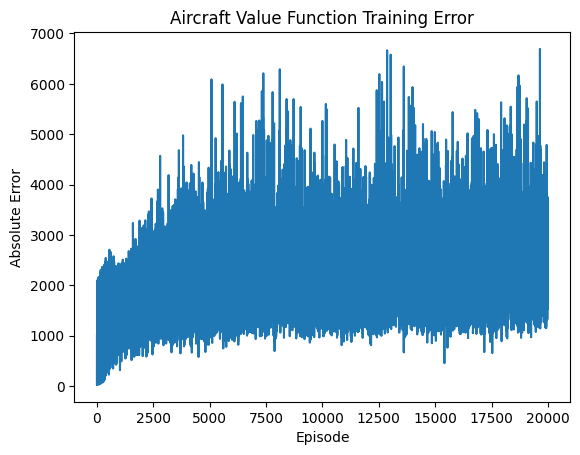

Streaming output truncated to the last 5000 lines.
Simulation finished.
Aircraft final score: 2000
Drone final score: 1000

Simulating game 3:
Simulation finished.
Aircraft final score: 0
Drone final score: 0

Simulating game 4:
Simulation finished.
Aircraft final score: 2000
Drone final score: 1000

Simulating game 5:
Simulation finished.
Aircraft final score: 2000
Drone final score: 1000

Simulating game 6:
Simulation finished.
Aircraft final score: 2000
Drone final score: 1000

Simulating game 7:
Simulation finished.
Aircraft final score: 2000
Drone final score: 1000

Simulating game 8:
Simulation finished.
Aircraft final score: 0
Drone final score: 0

Simulating game 9:
Simulation finished.
Aircraft final score: 0
Drone final score: 0

Simulating game 10:
Simulation finished.
Aircraft final score: 2000
Drone final score: 1000

Simulating game 11:
Simulation finished.
Aircraft final score: 0
Drone final score: 0

Simulating game 12:
Simulation finished.
Aircraft final score: -1000
D


Visualizing game 2:
Simulation finished.
Aircraft final score: 0
Drone final score: 0



Visualizing game 3:
Simulation finished.
Aircraft final score: 0
Drone final score: 0


Simulation finished.
Aircraft final score: -1000
Drone final score: 2000


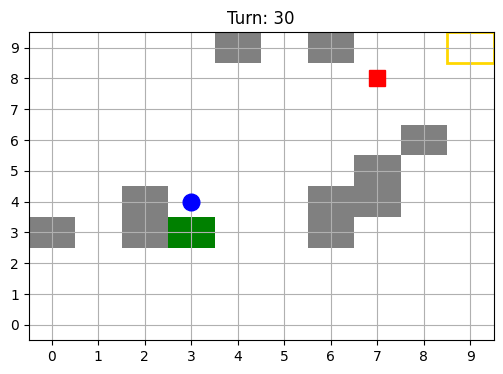

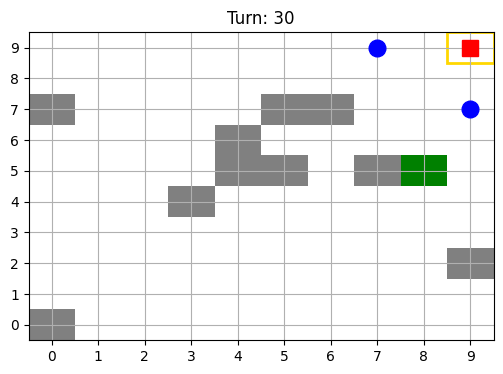

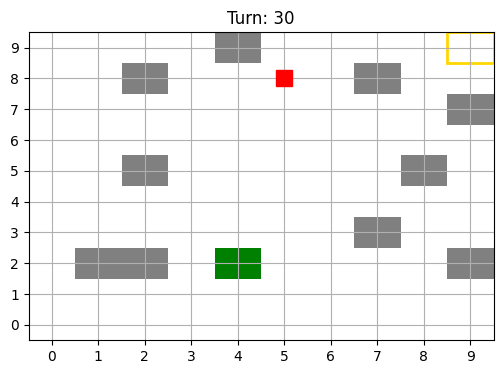

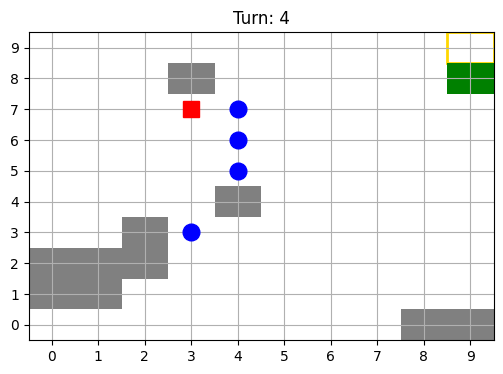

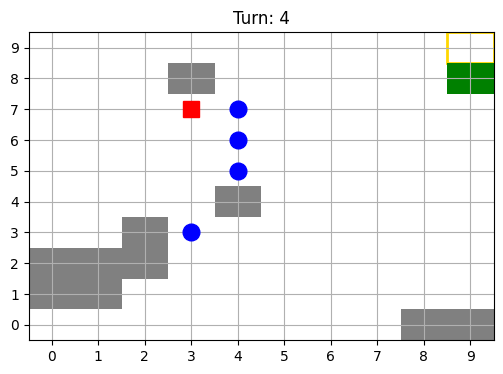

In [ ]:
# --- Main execution ---
if __name__ == "__main__":
    print("Training agents...")
    aircraft_vf, drone_vf = train_agents(num_episodes=20000, alpha=0.001)
    print("Training complete. Final weights saved to 'aircraft_weights.pkl' and 'drone_weights.pkl'.")

    # Simulate a few games using the learned weights
    num_games = 1000
    aircraft_wins = 0
    for i in range(num_games):
        print(f"\nSimulating game {i+1}:")
        states = simulate_game(aircraft_vf, drone_vf, display=False)
        # Check if the aircraft won
        if states[-1]['aircraft'] == states[-1]['goal'] and len(states[-1]['drones']) == 0:
            aircraft_wins += 1

    # Calculate and print the win percentage
    win_percentage = (aircraft_wins / num_games) * 100
    print(f"\nAircraft win percentage over {num_games} games: {win_percentage:.2f}%")

    # Visualize 3 games
    for i in range(3):
        print(f"\nVisualizing game {i + 1}:")
        states = simulate_game(aircraft_vf, drone_vf, display=False)

        ani = display_game(states)
        display(ani)  # Display the animation in the notebook

# Display the final game
states = simulate_game(aircraft_vf, drone_vf, display=True)
display_game(states)

In [4]:
def load_and_display_weights(file_path):
    with open(file_path, 'rb') as file:
        weights = pickle.load(file)
        print(f"Contents of {file_path}:")
        print(weights)

load_and_display_weights('drone_weights.pkl')
load_and_display_weights('aircraft_weights.pkl')

Contents of drone_weights.pkl:
[ 4.81005163e+02  2.44410364e+01  1.84034780e+01 -8.48472116e+00
 -1.27270817e+01  2.74201998e-01 -1.92599536e+01  5.68545318e+00
 -1.40542638e+01  2.11115194e+01  1.28495736e+02 -4.21851179e+01
  6.81622320e+01]
Contents of aircraft_weights.pkl:
[-282.77333152   19.80028055   14.85199016  224.06179193  399.07306961
  330.25812301  290.216225    138.54573771    7.57152035   19.51231734
 -325.65641356  -62.57254206  -68.89689573   35.90313319  248.31121907
 -202.89086434  151.65001782 -140.20486123]
